# RavenStack SaaS Churn & Customer Health Analysis
- This notebook analyzes a mutli-table Saas dataset to understand customer churn, subscription revenue, product usage, support health and customer retention patterns.
- The goal is to validate dashboard KPI's explore business drivers of churn and generate insights for decision-making.

In [372]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

accounts = pd.read_csv('../data/ravenstack_accounts.csv')
churn_events = pd.read_csv('../data/ravenstack_churn_events.csv')
feature_usage = pd.read_csv('../data/ravenstack_feature_usage.csv')
subscriptions = pd.read_csv('../data/ravenstack_subscriptions.csv')
support_tickets = pd.read_csv('../data/ravenstack_support_tickets.csv')

In [373]:
for df in [accounts, subscriptions, feature_usage, support_tickets, churn_events]:
    df.columns = df.columns.str.strip()
print(accounts.columns.tolist())

['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']


In [374]:
datasets = {
    "accounts": accounts,
    "churn_events": churn_events,
    "feature_usage": feature_usage,
    "subscriptions": subscriptions,
    "support_tickets": support_tickets
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

accounts: 500 rows, 10 columns
churn_events: 600 rows, 9 columns
feature_usage: 25000 rows, 8 columns
subscriptions: 5000 rows, 14 columns
support_tickets: 2000 rows, 9 columns


In [375]:
for name, df in datasets.items():
    print(f"\n{name}")
    display(df.head())


accounts


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True



churn_events


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive



feature_usage


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



subscriptions


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True



support_tickets


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


## Data Preparation

In [376]:
accounts["signup_date"] = pd.to_datetime(accounts["signup_date"])
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])
support_tickets["submitted_at"] = pd.to_datetime(support_tickets["submitted_at"])
support_tickets["closed_at"] = pd.to_datetime(support_tickets["closed_at"])
churn_events["churn_date"] = pd.to_datetime(churn_events["churn_date"])

for name, df in datasets.items():
    print(f"\n{name} data types:")
    print(df.dtypes)


accounts data types:
account_id                 object
account_name               object
industry                   object
country                    object
signup_date        datetime64[ns]
referral_source            object
plan_tier                  object
seats                       int64
is_trial                     bool
churn_flag                   bool
dtype: object

churn_events data types:
churn_event_id                      object
account_id                          object
churn_date                  datetime64[ns]
reason_code                         object
refund_amount_usd                  float64
preceding_upgrade_flag                bool
preceding_downgrade_flag              bool
is_reactivation                       bool
feedback_text                       object
dtype: object

feature_usage data types:
usage_id                       object
subscription_id                object
usage_date             datetime64[ns]
feature_name                   object
usage_count       

In [377]:
feature_usage = feature_usage.reset_index(drop=True)

if "usage_record_id" in feature_usage.columns:
    feature_usage = feature_usage.drop(columns=["usage_record_id"])

feature_usage.insert(
    0,
    "usage_record_id",
    range(1, len(feature_usage) +1)
)


datasets["feature_usage"] = feature_usage

## Data quality checks

In [378]:
missing_values = []

for name, df in datasets.items():
    missing_count = df.isnull().sum()
    missing_percent = (df.isnull().mean() * 100).round(2)

    summary = pd.DataFrame({
        "table": name,
        "column":missing_count.index,
        "missing_count": missing_count.values,
        "missing_percent": missing_percent.values
    })

    missing_values.append(summary)
missing_summary = pd.concat(missing_values, ignore_index=True)
missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(by=["missing_percent"], ascending=False)

,table,column,missing_count,missing_percent
31,subscriptions,end_date,4514,90.28
49,support_tickets,satisfaction_score,825,41.25
18,churn_events,feedback_text,148,24.67


## Relationship checks

In [379]:
relationship_checks = {
    "subscriptions.account_id not in accounts":
        subscriptions[
            ~subscriptions["account_id"].isin(accounts["account_id"])
        ].shape[0],

    "feature_usage.subscription_id not in subscriptions":
        feature_usage[
            ~feature_usage["subscription_id"].isin(subscriptions["subscription_id"])
        ].shape[0],

    "support_tickets.account_id not in accounts":
        support_tickets[
            ~support_tickets["account_id"].isin(accounts["account_id"])
        ].shape[0],

    "churn_events.account_id not in accounts":
        churn_events[
            ~churn_events["account_id"].isin(accounts["account_id"])
        ].shape[0]
}

pd.DataFrame(
    relationship_checks.items(),
    columns=["check", "missing_records"]
)

,check,missing_records
0,subscriptions.account_id not in accounts,0
1,feature_usage.subscription_id not in subscript...,0
2,support_tickets.account_id not in accounts,0
3,churn_events.account_id not in accounts,0


In [380]:
# Temporal consistency checks

usage_temporal_check = (
    feature_usage
    .merge(
        subscriptions[
            ["subscription_id", "account_id", "start_date", "end_date"]
        ],
        on="subscription_id",
        how="left"
    )
    .merge(
        accounts[["account_id", "signup_date"]],
        on="account_id",
        how="left"
    )
)

support_temporal_check = support_tickets.merge(
    accounts[["account_id", "signup_date"]],
    on="account_id",
    how="left"
)

temporal_quality_summary = pd.DataFrame({
    "check": [
        "Usage before account signup",
        "Usage before subscription start",
        "Usage after subscription end",
        "Support ticket before account signup"
    ],
    "records": [
        (
            usage_temporal_check["usage_date"]
            < usage_temporal_check["signup_date"]
        ).sum(),

        (
            usage_temporal_check["usage_date"]
            < usage_temporal_check["start_date"]
        ).sum(),

        (
            usage_temporal_check["end_date"].notna()
            & (
                usage_temporal_check["usage_date"]
                > usage_temporal_check["end_date"]
            )
        ).sum(),

        (
            support_temporal_check["submitted_at"]
            < support_temporal_check["signup_date"]
        ).sum()
    ]
})

temporal_quality_summary

,check,records
0,Usage before account signup,13198
1,Usage before subscription start,19142
2,Usage after subscription end,290
3,Support ticket before account signup,1077


## Duplicate checks

In [381]:
# Duplicate and identifier checks

identifier_columns = {
    "accounts": "account_id",
    "subscriptions": "subscription_id",
    "feature_usage": "usage_record_id",
    "support_tickets": "ticket_id",
    "churn_events": "churn_event_id"
}

duplicate_summary = []

for table_name, identifier in identifier_columns.items():
    df = datasets[table_name]

    duplicate_summary.append({
        "table": table_name,
        "identifier": identifier,
        "duplicate_identifier_count": df.duplicated(
            subset=[identifier]
        ).sum()
    })

duplicate_summary = pd.DataFrame(duplicate_summary)

duplicate_summary  

,table,identifier,duplicate_identifier_count
0,accounts,account_id,0
1,subscriptions,subscription_id,0
2,feature_usage,usage_record_id,0
3,support_tickets,ticket_id,0
4,churn_events,churn_event_id,0


In [382]:
# Source-level duplicate checks for feature usage

feature_usage_source_columns = [
    col for col in feature_usage.columns
    if col != "usage_record_id"
]

usage_quality_summary = pd.DataFrame({
    "check": [
        "Repeated source usage_id",
        "Exact duplicate source rows"
    ],
    "records": [
        feature_usage.duplicated(
            subset=["usage_id"]
        ).sum(),

        feature_usage.duplicated(
            subset=feature_usage_source_columns
        ).sum()
    ]
})

usage_quality_summary

,check,records
0,Repeated source usage_id,21
1,Exact duplicate source rows,0


### Duplicate note

No exact duplicate records were identified in the feature usage dataset.

However, 21 `usage_id` values were reused across different usage events.
Because these records contain different event-level information, they were
retained rather than removed.

A surrogate `usage_record_id` was created to provide a unique identifier for
each feature usage record while preserving the original source identifier.


## KPI Validation

In [383]:
total_accounts = accounts["account_id"].nunique()

churned_accounts = accounts.loc[
    accounts["churn_flag"],
    "account_id"
].nunique()

churn_rate = churned_accounts / total_accounts

active_mrr = subscriptions.loc[
    ~subscriptions["churn_flag"],
    "mrr_amount"
].sum()

active_arr = subscriptions.loc[
    ~subscriptions["churn_flag"],
    "arr_amount"
].sum()

total_tickets = len(support_tickets)

avg_satisfaction = support_tickets["satisfaction_score"].mean()

total_usage_count = feature_usage["usage_count"].sum()
total_errors = feature_usage["error_count"].sum()

error_rate = total_errors / total_usage_count

escalated_tickets = support_tickets["escalation_flag"].sum()
escalation_rate = escalated_tickets / total_tickets

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Accounts",
        "Churned Accounts",
        "Churn Rate",
        "Active MRR",
        "Active ARR",
        "Total Support Tickets",
        "Average Satisfaction Score",
        "Product Usage Error Rate",
        "Escalation Rate"
    ],
    "Value": [
        f"{total_accounts:,}",
        f"{churned_accounts:,}",
        f"{churn_rate:.2%}",
        f"${active_mrr:,.2f}",
        f"${active_arr:,.2f}",
        f"{total_tickets:,}",
        f"{avg_satisfaction:.2f}",
        f"{error_rate:.2%}",
        f"{escalation_rate:.2%}"
    ]
})

kpi_summary

,Metric,Value
0,Total Accounts,500
1,Churned Accounts,110
2,Churn Rate,22.00%
3,Active MRR,"$10,159,608.00"
4,Active ARR,"$121,915,296.00"
5,Total Support Tickets,"2,000"
6,Average Satisfaction Score,3.98
7,Product Usage Error Rate,5.63%
8,Escalation Rate,4.75%


### KPI Summary

- The dataset contains 500 accounts, with 110 churned accounts, resulting in a 22.0% account level churn rate. Active MRR is approximately $10.16M and active ARR approximately $121.92M. The average support satisfaction score is 3.98 out of 5, while the overall product error rate is 5.63% and the escalation rate is 4.75%

## Churn Analysis

In [384]:
churn_reason_summary = (
    churn_events
    .groupby("reason_code")
    .agg(
        churn_events=("churn_event_id", "count"),
        total_refund=("refund_amount_usd", "sum"),
        avg_refund=("refund_amount_usd", "mean")
    )
    .sort_values(by="churn_events", ascending=False)
)
churn_reason_summary

,churn_events,total_refund,avg_refund
reason_code,,,
features,114,1905.90,16.718421
budget,104,1247.54,11.995577
support,104,1219.64,11.727308
unknown,95,1742.39,18.340947
competitor,92,1203.53,13.081848
pricing,91,1333.25,14.651099


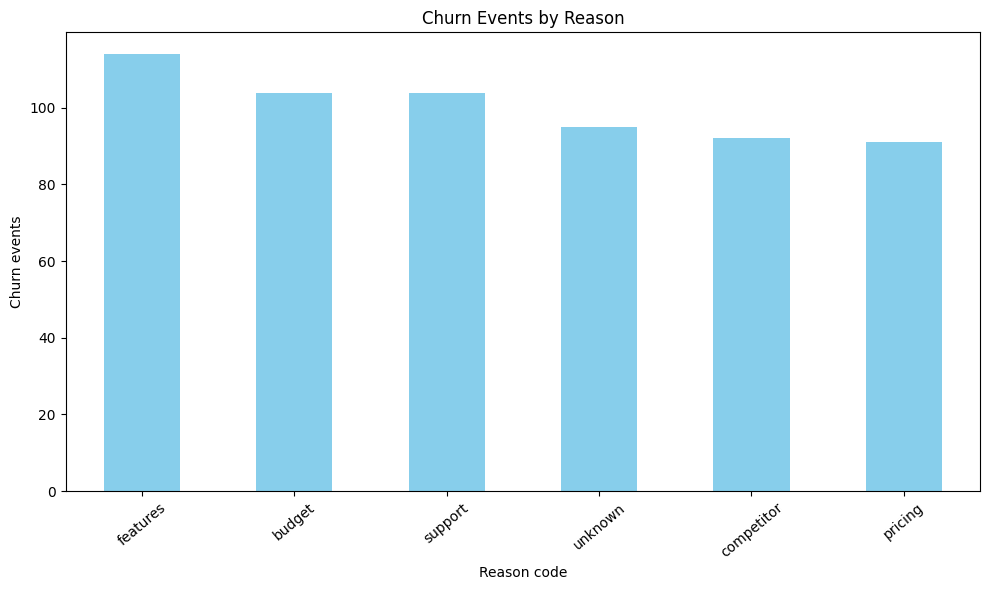

In [385]:
plt.figure(figsize=(10,6))

churn_reason_summary["churn_events"].plot(kind="bar", color="skyblue")

plt.title("Churn Events by Reason")
plt.xlabel("Reason code")
plt.ylabel("Churn events")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

In [386]:
referral_churn = (
    accounts
    .groupby("referral_source")
    .agg(
        total_accounts=("account_id", "nunique"),
        churned_accounts=("churn_flag", "sum")
    )
)

referral_churn["churn_rate"] = (
    referral_churn["churned_accounts"] / referral_churn["total_accounts"]
)

referral_churn = referral_churn.sort_values(by="churn_rate", ascending=False)

referral_churn


,total_accounts,churned_accounts,churn_rate
referral_source,,,
event,96,29,0.302083
other,103,25,0.242718
ads,98,23,0.234694
organic,114,20,0.175439
partner,89,13,0.146067


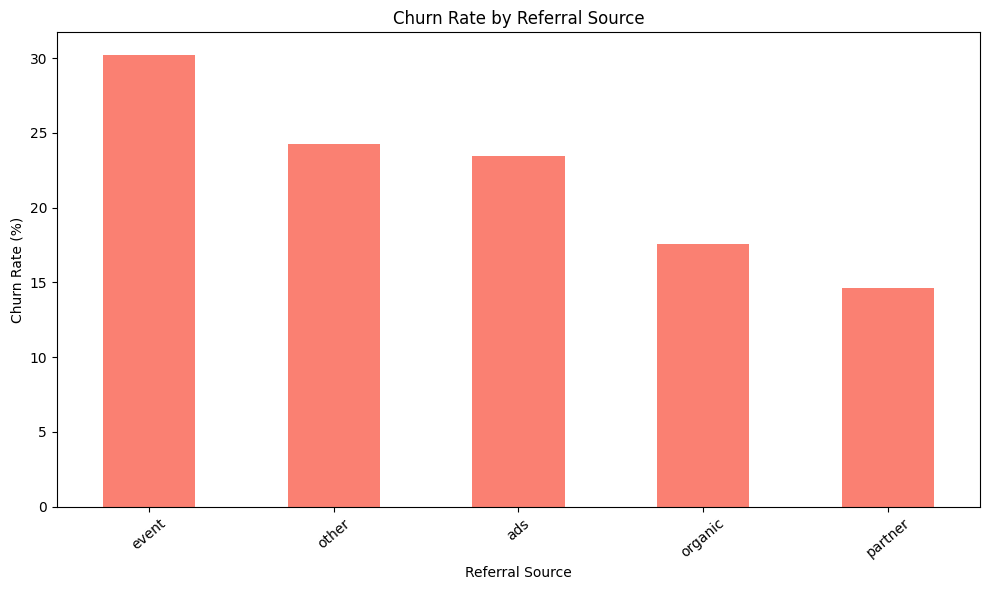

In [387]:
plt.figure(figsize=(10,6))
(referral_churn["churn_rate"] * 100).plot(kind="bar", color="salmon")
plt.title("Churn Rate by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

In [388]:
plan_churn = (
    subscriptions
    .groupby("plan_tier")
    .agg(
        total_subscriptions=("subscription_id", "nunique"),
        churned_subscriptions=("churn_flag", "sum")
    )
)

plan_churn["subscriptions_churn_rate"] = (
    plan_churn["churned_subscriptions"] / plan_churn["total_subscriptions"]
)

plan_churn = plan_churn.sort_values(by="subscriptions_churn_rate", ascending=False)
plan_churn

,total_subscriptions,churned_subscriptions,subscriptions_churn_rate
plan_tier,,,
Enterprise,1723,172,0.099826
Pro,1675,162,0.096716
Basic,1602,152,0.094881


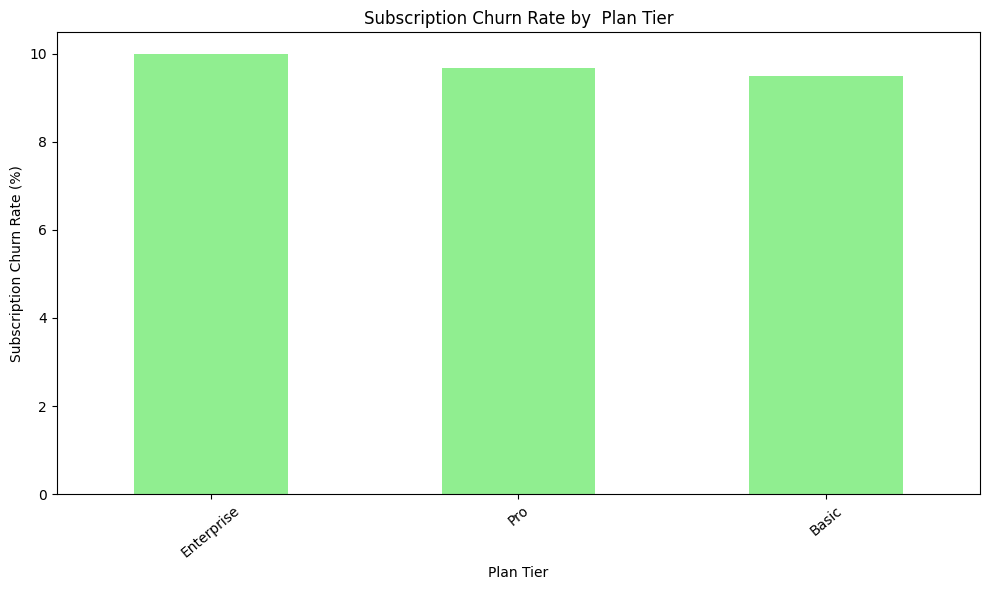

In [389]:
plt.figure(figsize=(10,6))
(plan_churn["subscriptions_churn_rate"] * 100).plot(kind="bar", color="lightgreen")
plt.title("Subscription Churn Rate by  Plan Tier")
plt.xlabel("Plan Tier")
plt.ylabel("Subscription Churn Rate (%)")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

In [390]:
churn_events["churn_month"] = churn_events["churn_date"].dt.to_period("M").dt.to_timestamp()

monthly_churn = (
    churn_events
    .groupby("churn_month")
    .agg(
        churn_events=("churn_event_id", "count"),
        total_refund=("refund_amount_usd", "sum"),
    )
    .sort_index()
)

monthly_churn.tail()

,churn_events,total_refund
churn_month,,
2024-08-01,42,829.47
2024-09-01,53,1019.21
2024-10-01,66,832.18
2024-11-01,68,732.06
2024-12-01,117,2146.08


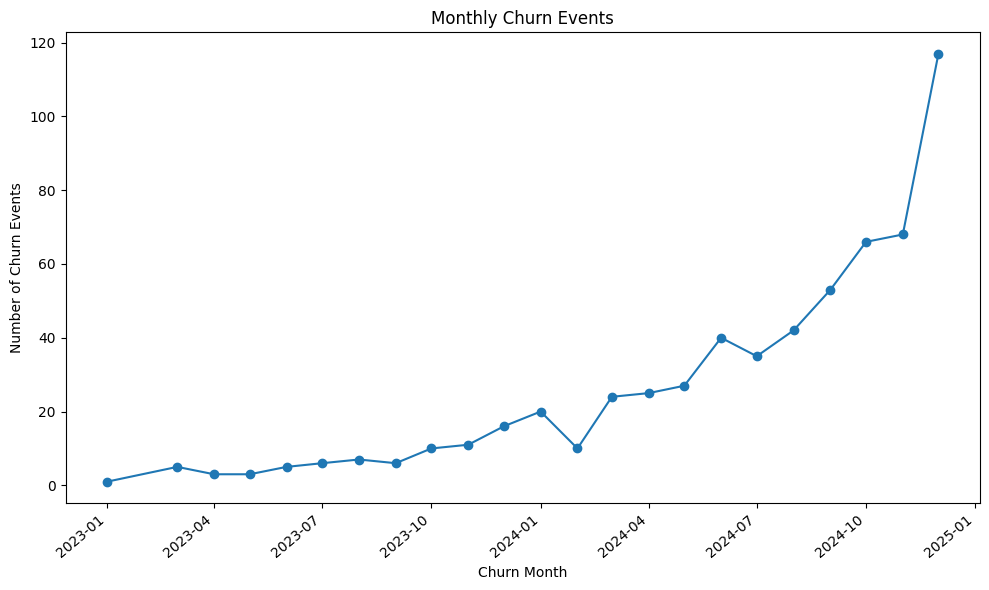

In [391]:
plt.figure(figsize=(10,6))
monthly_churn["churn_events"].plot(kind="line", marker ="o")
plt.title("Monthly Churn Events")
plt.xlabel("Churn Month")
plt.ylabel("Number of Churn Events")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

### Churn Analysis Findings

- Feature-related churn is the most common churn reason, followed by budget and support-related churn.
- Event-sourced accounts show the highest churn rate among referral sources, while partner-sourced accounts show the lowest churn rate.
- Subscription churn rates are relatively close across plan tiers, with Enterprise subscriptions showing the highest churn rate.
- Monthly churn events show an increasing trend over time, with a noticeable spike toward the end of 2024.

## Revenue Analysis

In [392]:
revenue_by_plan = (
    subscriptions
    .groupby("plan_tier")
    .agg(
        total_mrr=("mrr_amount", "sum"),
        active_mrr=("mrr_amount", lambda x: x[ ~subscriptions.loc[x.index, "churn_flag"]].sum()),
        total_arr=("arr_amount", "sum"),
        active_subscriptions=("churn_flag", lambda x: (~x).sum()),
        churned_subscriptions=("churn_flag", "sum")
    )
    .sort_values(by="active_mrr", ascending=False)
)
revenue_by_plan 

,total_mrr,active_mrr,total_arr,active_subscriptions,churned_subscriptions
plan_tier,,,,,
Enterprise,8473221,7546876,101678652,1551,172
Pro,2105089,1924818,25261068,1513,162
Basic,760437,687914,9125244,1450,152


In [393]:
revenue_by_plan["active_mrr_share_of_total"]= (
    revenue_by_plan["active_mrr"] / revenue_by_plan["active_mrr"].sum()
)
revenue_by_plan["active_mrr_retention_ratio"]= (
    revenue_by_plan["active_mrr"] / revenue_by_plan["total_mrr"]
)

revenue_by_plan

,total_mrr,active_mrr,total_arr,active_subscriptions,churned_subscriptions,active_mrr_share_of_total,active_mrr_retention_ratio
plan_tier,,,,,,,
Enterprise,8473221,7546876,101678652,1551,172,0.742831,0.890674
Pro,2105089,1924818,25261068,1513,162,0.189458,0.914364
Basic,760437,687914,9125244,1450,152,0.067711,0.904630


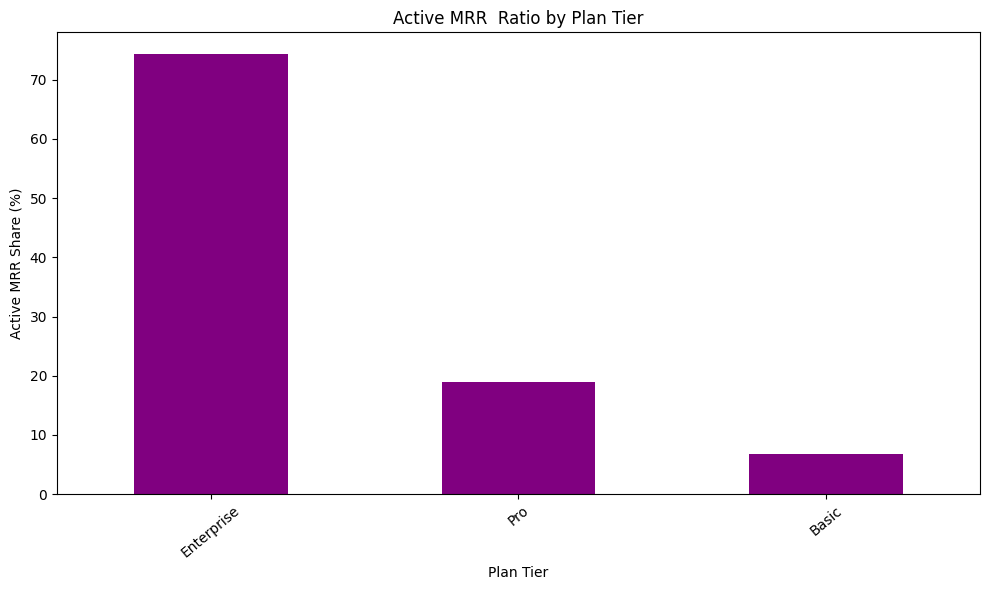

In [394]:
plt.figure(figsize=(10,6))
(revenue_by_plan["active_mrr_share_of_total"]*100).plot(kind="bar", color="purple")
plt.title("Active MRR  Ratio by Plan Tier")
plt.xlabel("Plan Tier")
plt.ylabel("Active MRR Share (%)")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

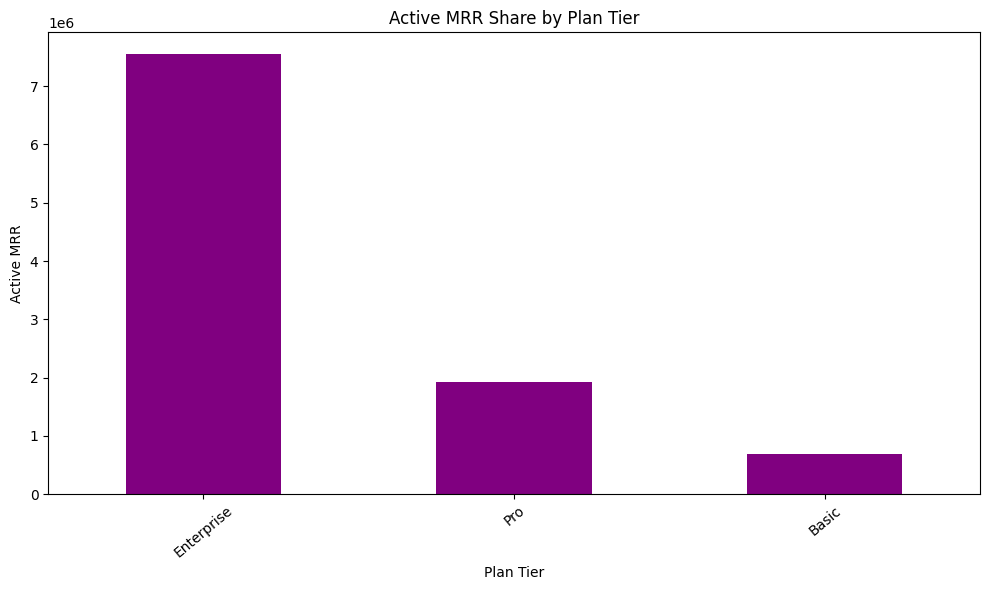

In [395]:
plt.figure(figsize=(10,6))

revenue_by_plan["active_mrr"].plot(kind="bar", color="purple")
plt.title("Active MRR Share by Plan Tier")
plt.xlabel("Plan Tier")
plt.ylabel("Active MRR")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

### Revenue Analysis Findings
- Enterprise is the dominant revenue segment, generating roughly three quarters of total active MRR.
- Pro contributes a smaller but still meaningful share of active MRR, while Basic contributes the lowest revenue share.
- Active MRR is highly concentrated in Enterprise accounts, meaning retention in this segment has the largest revenue impact.
- Although Enterprise shows the highest subscription churn rate, it still remains the most important plan tier from a revenue perspective.

## Product Usage Analysis

In [396]:
feature_summary = (
    feature_usage
    .groupby("feature_name")
    .agg(
        total_usage=("usage_count", "sum"),
        total_errors=("error_count", "sum"),
        avg_duration_secs=("usage_duration_secs", "mean"),
        usage_events=("usage_record_id", "count")
    )
)

feature_summary["error_rate"] = (
    feature_summary["total_errors"] / feature_summary["total_usage"]
)
feature_summary = feature_summary.sort_values(by="total_usage", ascending=False)

feature_summary.head(10)

,total_usage,total_errors,avg_duration_secs,usage_events,error_rate
feature_name,,,,,
feature_32,6686,357,3114.288316,659,0.053395
feature_15,6621,349,3073.418750,640,0.052711
feature_6,6546,339,3074.766412,655,0.051787
feature_20,6541,308,3028.293935,643,0.047088
feature_34,6536,397,3087.263077,650,0.060741
feature_12,6534,359,3128.195751,659,0.054943
feature_11,6533,352,3130.293935,643,0.053880
feature_2,6525,401,3015.099688,642,0.061456
feature_38,6478,356,3020.617418,643,0.054955


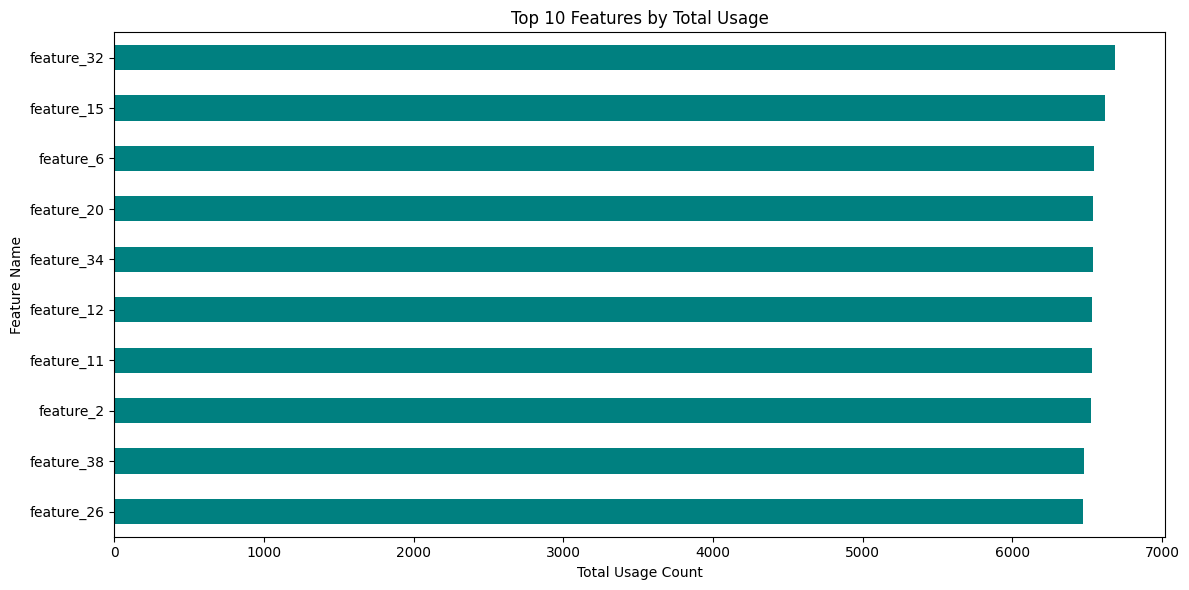

In [397]:
top_10_features = feature_summary.head(10)
plt.figure(figsize=(12,6))
top_10_features["total_usage"].sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 Features by Total Usage")
plt.xlabel("Total Usage Count")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

In [398]:
top_error_features = feature_summary.sort_values(by="total_errors", ascending=False).head(10)
top_error_features

,total_usage,total_errors,avg_duration_secs,usage_events,error_rate
feature_name,,,,,
feature_4,6374,418,3149.795200,625,0.065579
feature_26,6470,417,3045.265023,649,0.064451
feature_9,6207,404,3007.133013,624,0.065088
feature_2,6525,401,3015.099688,642,0.061456
feature_34,6536,397,3087.263077,650,0.060741
feature_16,6273,396,3139.081994,622,0.063128
feature_40,6222,380,3109.829308,621,0.061074
feature_13,6099,372,2962.410131,612,0.060994
feature_29,6362,371,2998.842187,640,0.058315


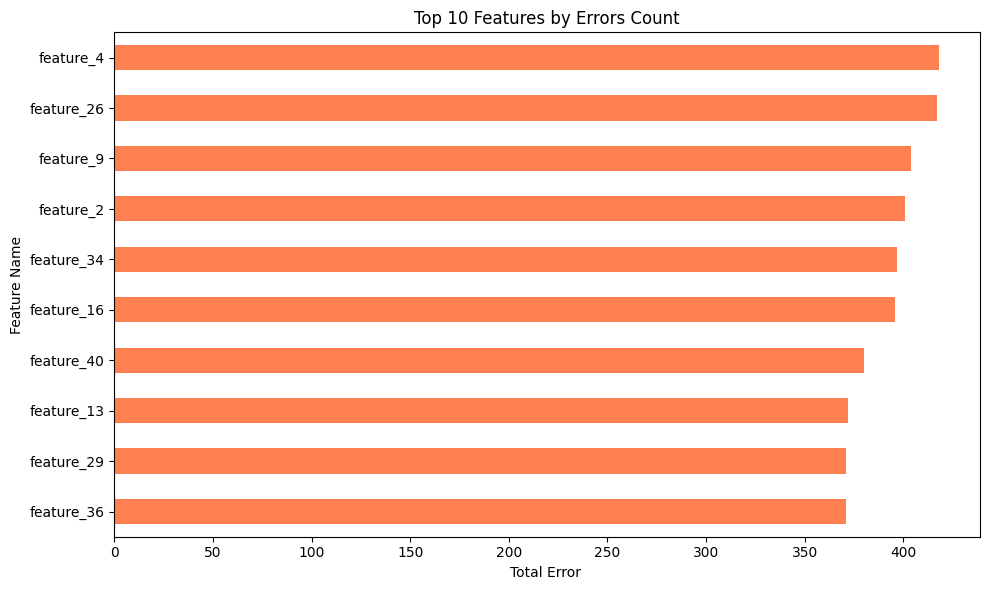

In [399]:
plt.figure(figsize=(10,6))
top_error_features["total_errors"].sort_values().plot(kind="barh", color="coral")
plt.title("Top 10 Features by Errors Count")
plt.xlabel("Total Error ")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

In [400]:
high_usage_features = feature_summary[
    feature_summary["total_usage"] >= feature_summary["total_usage"].median()
]
highest_error_rate_features = (
    high_usage_features
    .sort_values(by="error_rate", ascending=False)
    .head(10)
)

highest_error_rate_features

,total_usage,total_errors,avg_duration_secs,usage_events,error_rate
feature_name,,,,,
feature_4,6374,418,3149.795200,625,0.065579
feature_26,6470,417,3045.265023,649,0.064451
feature_2,6525,401,3015.099688,642,0.061456
feature_34,6536,397,3087.263077,650,0.060741
feature_36,6389,371,2893.259259,648,0.058069
feature_17,6458,369,2996.662058,651,0.057138
feature_39,6430,357,3082.825674,631,0.055521
feature_38,6478,356,3020.617418,643,0.054955
feature_12,6534,359,3128.195751,659,0.054943


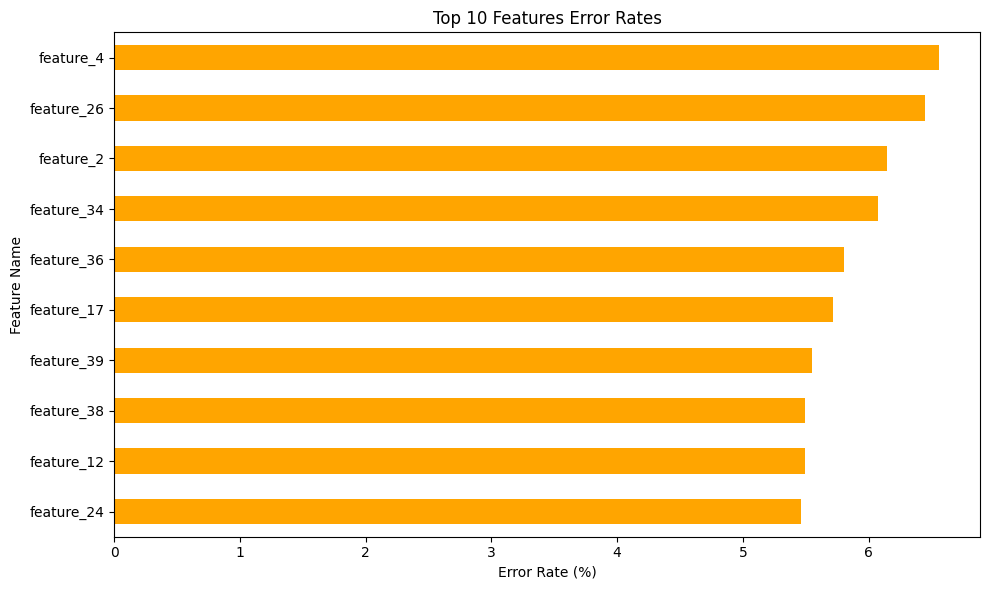

In [401]:
plt.figure(figsize=(10,6))
(highest_error_rate_features["error_rate"]*100).sort_values().plot(kind="barh", color="orange")
plt.title("Top 10 Features Error Rates")
plt.xlabel("Error Rate (%)")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()  

In [402]:
beta_feature_summary = (
    feature_usage
    .groupby("is_beta_feature")
    .agg(
        total_usage=("usage_count", "sum"),
        total_errors=("error_count", "sum"),
        usage_events=("usage_record_id", "count"),
        avg_duration_secs=("usage_duration_secs", "mean")
    )
)

beta_feature_summary["error_rate"] = (
    beta_feature_summary["total_errors"] / beta_feature_summary["total_usage"]
)

beta_feature_summary

,total_usage,total_errors,usage_events,avg_duration_secs,error_rate
is_beta_feature,,,,,
False,224939,12691,22456,3041.384129,0.056420
True,25586,1416,2544,3049.430031,0.055343


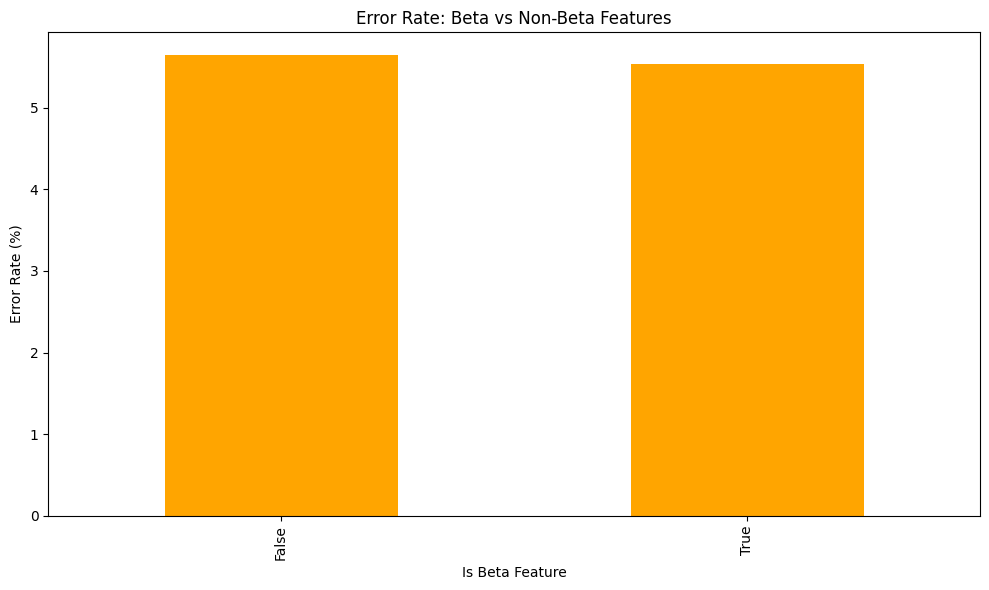

In [403]:
plt.figure(figsize=(10,6))

(beta_feature_summary["error_rate"]*100).plot(kind="bar", color="orange")
plt.title("Error Rate: Beta vs Non-Beta Features")
plt.xlabel("Is Beta Feature")
plt.ylabel("Error Rate (%)")
plt.tight_layout()
plt.show()

### Product Usage Analysis Findings

- The feature usage is distributed across multiple high activity features, with feature_32, feature_15 and feature_6 among the most used features.
- Raw error count and error rate provide different perspectives. Some features generate many errors because they are heavily used, while others show higher error rates relative to usage.
- feature_26, feature_2 and feature_34 stand out with relatively high error rates among commonly used features.
- Beta and non-beta features show very similar erro rates, suggesting that beta status alone does not explain product error behavior.

## Support Health Analysis

In [404]:
# Support summary by priority level

support_by_priority = (
    support_tickets
    .groupby("priority")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_satisfaction=("satisfaction_score", "mean"),
        avg_resolution_hours=("resolution_time_hours", "mean"),
        avg_first_response_minutes=("first_response_time_minutes", "mean"),
        escalated_tickets=("escalation_flag", "sum")    
    )
)

support_by_priority["escalation_rate"] = (
    support_by_priority["escalated_tickets"] / support_by_priority["ticket_count"]
)

priority_order = ["low", "medium", "high", "urgent"]

support_by_priority = support_by_priority.reindex(priority_order)
support_by_priority

,ticket_count,avg_satisfaction,avg_resolution_hours,avg_first_response_minutes,escalated_tickets,escalation_rate
priority,,,,,,
low,485,4.020906,36.346392,91.152577,23,0.047423
medium,491,3.934932,35.594705,85.855397,25,0.050916
high,510,3.996610,36.958824,91.439216,24,0.047059
urgent,514,3.973422,34.568093,85.529183,23,0.044747


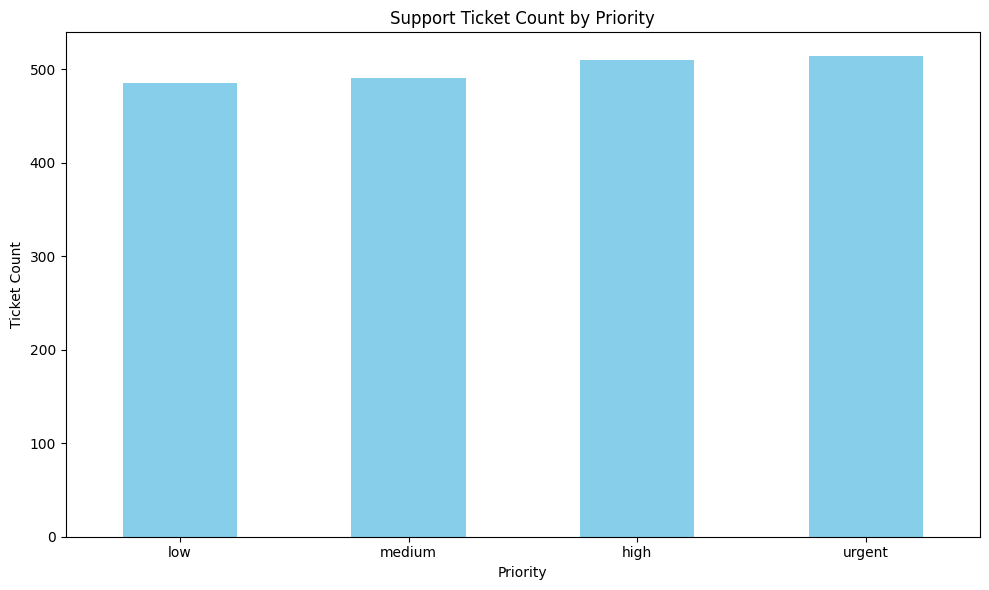

In [405]:
# Ticket count by priority visualization

plt.figure(figsize=(10,6))
support_by_priority["ticket_count"].plot(kind="bar", color="skyblue")
plt.title("Support Ticket Count by Priority")
plt.xlabel("Priority")
plt.ylabel("Ticket Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

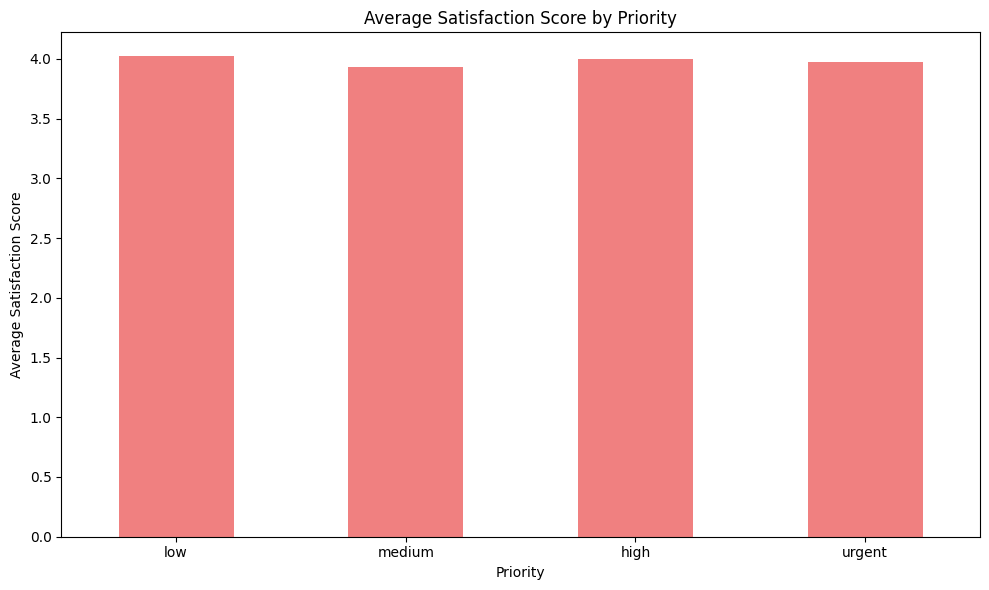

In [406]:
#Avg satisfaction score by priority visualization

plt.figure(figsize=(10,6))
support_by_priority["avg_satisfaction"].plot(kind="bar", color="lightcoral")

plt.title("Average Satisfaction Score by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Satisfaction Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

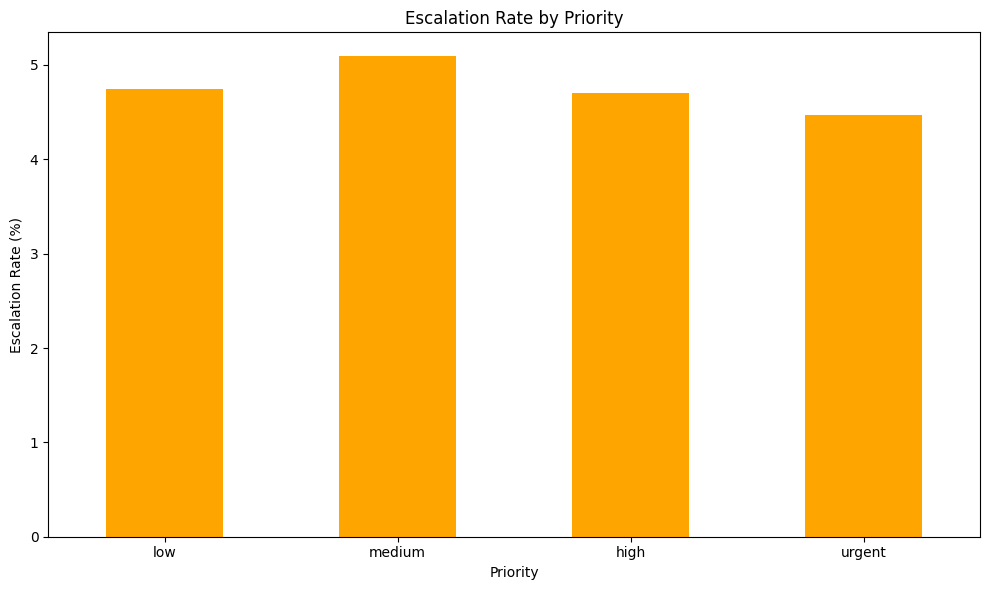

In [407]:
# Escalation rate by priority visualization

plt.figure(figsize=(10,6))
(support_by_priority["escalation_rate"]*100).plot(kind="bar", color="orange")
plt.title("Escalation Rate by Priority")
plt.xlabel("Priority")
plt.ylabel("Escalation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

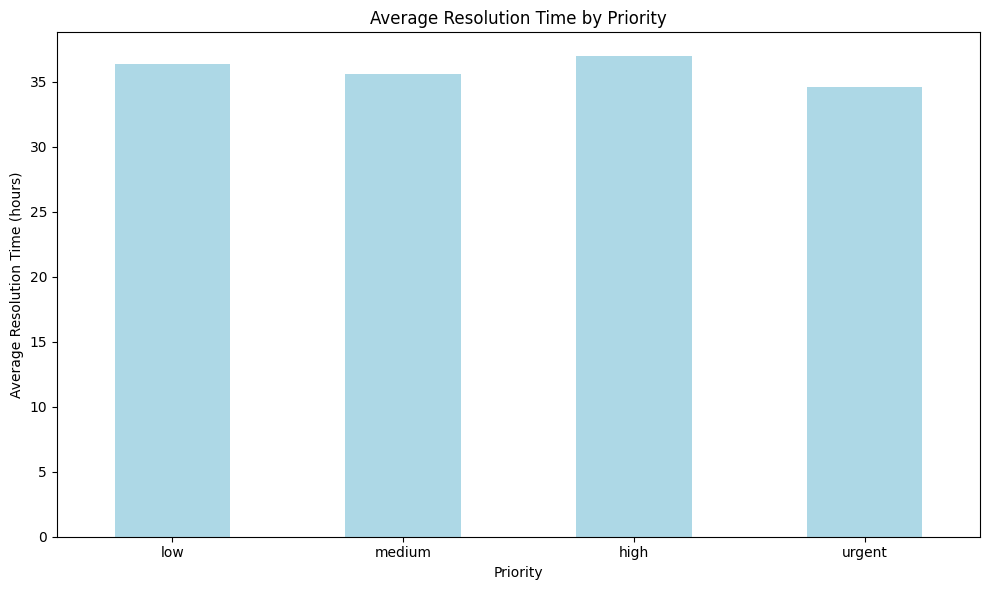

In [408]:
#Resolution time by priority visualization

plt.figure(figsize=(10,6))
support_by_priority["avg_resolution_hours"].plot(kind="bar", color="lightblue")

plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Time (hours)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Support Health Analysis Findings

- Support ticket volume is relatively balanced across priority levels.
- Average satisfaction remains close to 4 out of 5 across priorities.
- Escalation rate is approximately 4.75% overall, indicating that only a small portion of support tickets required escalation.
- Resolution time and escalation behavior can be used as operational health for customer support performance.


## Exploratory Customer Risk Segmentation

In [409]:
account_usage = (
    feature_usage
    .merge(
        subscriptions[["subscription_id", "account_id"]],
        on="subscription_id",
        how="left"
    )
    .groupby("account_id")
    .agg(
        total_usage_count=("usage_count", "sum"),
        total_errors=("error_count", "sum"),
        usage_events=("usage_record_id", "count"),
        avg_usage_duration_secs=("usage_duration_secs", "mean")
    )
)

account_usage["error_rate"] = (
    account_usage["total_errors"] / account_usage["total_usage_count"]
)

account_usage.head()
        

,total_usage_count,total_errors,usage_events,avg_usage_duration_secs,error_rate
account_id,,,,,
A-00bed1,514,27,51,2818.313725,0.052529
A-00cac8,602,31,58,2954.586207,0.051495
A-0158bb,364,22,36,3390.305556,0.060440
A-016043,490,21,47,2810.106383,0.042857
A-019782,562,30,55,2924.509091,0.053381


In [410]:
#Account level support ticket summary

account_support = (
    support_tickets
    .groupby("account_id")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_satisfaction=("satisfaction_score", "mean"),
        avg_resolution_hours=("resolution_time_hours", "mean"),
        escalated_tickets=("escalation_flag","sum")
    )
)

account_support["escalation_rate"] = (
    account_support["escalated_tickets"] / account_support["ticket_count"]
)

account_support.head()

,ticket_count,avg_satisfaction,avg_resolution_hours,escalated_tickets,escalation_rate
account_id,,,,,
A-00bed1,4,4.0,31.750000,0,0.0
A-00cac8,2,NaN,33.000000,0,0.0
A-0158bb,1,3.0,32.000000,0,0.0
A-016043,3,4.0,30.333333,0,0.0
A-019782,2,3.0,10.000000,0,0.0


In [ ]:
#Account level revenue summary

account_revenue = (
    subscriptions
    .groupby("account_id")
    .agg(
        total_mrr=("mrr_amount", "sum"),
        active_mrr=(
            "mrr_amount",
            lambda x: x[
                ~subscriptions.loc[x.index, "churn_flag"]
            ].sum()
        ),
        subscription_count=("subscription_id", "count"),
        churned_subscriptions=("churn_flag", "sum")
    )
)

account_revenue.head()

,total_mrr,active_mrr,subscription_count,churned_subscriptions
account_id,,,,
A-00bed1,33506,33506,10,0
A-00cac8,14121,14121,9,0
A-0158bb,4070,4070,6,0
A-016043,16516,11740,11,1
A-019782,8353,5169,9,1


In [412]:
#Creating customer health dataset for churned and active comparison

customer_health = (
    accounts
    .merge(account_usage, on="account_id", how="left")
    .merge(account_support, on="account_id", how="left")
    .merge(account_revenue, on="account_id", how="left")
)

customer_health["total_usage"] = customer_health["total_usage_count"].fillna(0)
customer_health["total_errors"] = customer_health["total_errors"].fillna(0)
customer_health["usage_events"] = customer_health["usage_events"].fillna(0)
customer_health["ticket_count"] = customer_health["ticket_count"].fillna(0)
customer_health["escalated_tickets"] = customer_health["escalated_tickets"].fillna(0)
customer_health["avg_satisfaction"] = customer_health["avg_satisfaction"].fillna(customer_health["avg_satisfaction"].mean())
customer_health["error_rate"] = customer_health["error_rate"].fillna(0)
customer_health["escalation_rate"] = customer_health["escalation_rate"].fillna(0)

customer_health.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,total_usage_count,total_errors,usage_events,avg_usage_duration_secs,error_rate,ticket_count,avg_satisfaction,avg_resolution_hours,escalated_tickets,escalation_rate,total_mrr,active_mrr,subscription_count,churned_subscriptions,total_usage
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,535,38,55,2769.800000,0.071028,2.0,3.000000,23.000000,0.0,0.000000,12603,12603,10,0,535
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,355,14,35,2889.600000,0.039437,3.0,4.000000,38.000000,0.0,0.000000,10004,10004,8,0,355
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,821,48,83,3026.626506,0.058465,3.0,4.666667,43.666667,0.0,0.000000,18286,13311,15,3,821
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False,382,21,41,2500.682927,0.054974,2.0,3.964163,29.000000,0.0,0.000000,9275,9275,7,0,382
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,579,31,58,3720.327586,0.053541,7.0,3.800000,42.285714,1.0,0.142857,48761,25355,9,2,579


In [413]:
customer_health_comparison = (
    customer_health
    .groupby("churn_flag")
    .agg(
        accounts=("account_id", "nunique"),
        avg_total_usage=("total_usage", "mean"),
        avg_error_rate=("error_rate", "mean"),
        avg_ticket_count=("ticket_count", "mean"),
        avg_satisfaction=("avg_satisfaction", "mean"),
        avg_active_mrr=("active_mrr", "mean"),
    )
)

customer_health_comparison 


,accounts,avg_total_usage,avg_error_rate,avg_ticket_count,avg_satisfaction,avg_active_mrr
churn_flag,,,,,,
False,390,495.130769,0.057219,4.020513,3.954113,20734.500000
True,110,522.036364,0.053858,3.927273,3.999796,18846.845455


In [414]:
#Create risk segmentation

customer_health["risk_score"] = 0

customer_health.loc[
    customer_health["total_usage"] < customer_health["total_usage"].median(), "risk_score"
] += 1

customer_health.loc[
    customer_health["error_rate"] > customer_health["error_rate"].median(), "risk_score"
] += 1

customer_health.loc[
    customer_health["avg_satisfaction"] < customer_health["avg_satisfaction"].median(), "risk_score"
] += 1

customer_health.loc[
    customer_health["escalation_rate"] > customer_health["escalation_rate"].median(), "risk_score"
] += 1  

customer_health["risk_segment"] = pd.cut(
    customer_health["risk_score"],
    bins = [-1, 1, 2, 4],
    labels = ["Low Risk", "Medium Risk", "High Risk"]
)

customer_health[[
    "account_id",
    "account_name",
    "industry",
    "plan_tier",
    "churn_flag",
    "total_usage",
    "error_rate",
    "avg_satisfaction",
    "escalation_rate",
    "risk_score",
    "risk_segment"
]].head()

,account_id,account_name,industry,plan_tier,churn_flag,total_usage,error_rate,avg_satisfaction,escalation_rate,risk_score,risk_segment
0,A-2e4581,Company_0,EdTech,Basic,False,535,0.071028,3.000000,0.000000,2,Medium Risk
1,A-43a9e3,Company_1,FinTech,Basic,True,355,0.039437,4.000000,0.000000,1,Low Risk
2,A-0a282f,Company_2,DevTools,Basic,False,821,0.058465,4.666667,0.000000,1,Low Risk
3,A-1f0ac7,Company_3,HealthTech,Basic,False,382,0.054974,3.964163,0.000000,3,High Risk
4,A-ce550d,Company_4,HealthTech,Enterprise,True,579,0.053541,3.800000,0.142857,2,Medium Risk


In [415]:
#Risk segment summary

risk_segment_summary = (
    customer_health
    .groupby("risk_segment", observed=True)
    .agg(
        accounts=("account_id", "nunique"),
        churned_accounts=("churn_flag","sum"),
        avg_satisfaction=("avg_satisfaction", "mean"),
        avg_error_rate=("error_rate", "mean"),
        avg_active_mrr=("active_mrr", "mean")
    )
)

risk_segment_summary["churn_rate"] = (
    risk_segment_summary["churned_accounts"] / risk_segment_summary["accounts"]
)

risk_segment_summary

,accounts,churned_accounts,avg_satisfaction,avg_error_rate,avg_active_mrr,churn_rate
risk_segment,,,,,,
Low Risk,237,52,4.160715,0.050315,22714.000000,0.219409
Medium Risk,178,42,3.887175,0.059276,18660.786517,0.235955
High Risk,85,16,3.577353,0.067813,17114.941176,0.188235


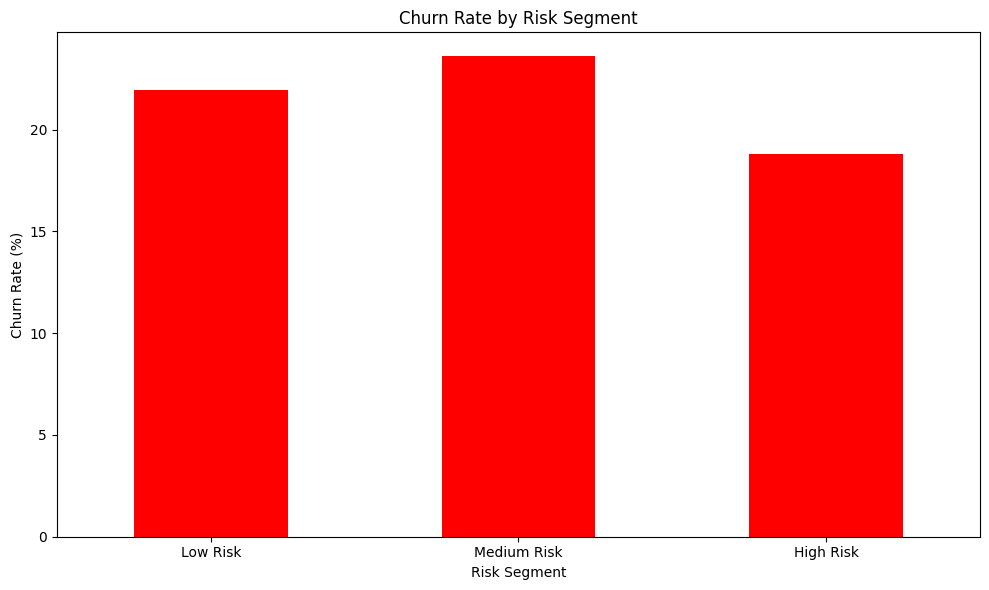

In [416]:
#Graph of risk segment 

plt.figure(figsize=(10,6))

(risk_segment_summary["churn_rate"]*100).plot(kind="bar", color="red")

plt.title("Churn Rate by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Customer Health/ Risk Analysis Findings

- Account-level usage, support and revenue metrices were combined to create a customer health view.
- Churned accounts do not show clearly worse usage or support health compared to active accounts in this dataset.
- Churned accounts have slightly lower average active MRR but their average usage and satisfaction metrics are similar to or slightly higher than active accounts.
- The rule-based risk score does not strongly separate churned and active customers. Medium-risk accounts show the highest churn rate, while high-risk accounts do not have the highest churn rate.
- This suggests that churn is not fully explained by product usage and support health alone. Referral source, churn reason and revenue segment appear to provide stronger business signals.



## Overall Key Findings
1. The dataset contains 500 accounts,  5,000 subscriptions, 25,000 feature usage records, 2,000 support tickets and 600 churn events.
2. Account level churn rate is 22.0% with 110 churned accounts out of 500 total accounts.
3. Active MRR is approximately $10.16M and Active ARR is approximately $121.92M.
4. Enterprise is the dominant revenue segment, generating roughly three quarters of total active MRR.
5. Feature related churn is the most frequent churn reason, followed by budget and support related churn.
6. Event sourced accounts show the highest churn rate among referral sources.
7. Product error rate is approximately 5.63% while beta and non-beta features show very similar error rates.
8. Average support satisfaction is 3.98 out of 5, and escalation rate is approximately 4.75%.
9. Usage and support health metrics alone do not clearly explain churn behavior in this dataset.

## SQL Database Export

In [418]:
import sqlite3 
from pathlib import Path

db_path = Path("../sql/ravenstack.db")
db_path.parent.mkdir(exist_ok=True)

conn = sqlite3.connect(db_path)

accounts.to_sql("accounts", conn, if_exists="replace", index=False)
subscriptions.to_sql("subscriptions", conn, if_exists="replace", index=False)
feature_usage.to_sql("feature_usage", conn, if_exists="replace", index=False)
support_tickets.to_sql("support_tickets", conn, if_exists="replace", index=False)
churn_events.to_sql("churn_events", conn, if_exists="replace", index=False)

conn.close()

print("SQLite database created at:", db_path)

SQLite database created at: ..\sql\ravenstack.db
